### `Loading libraries`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer


### `Fetching Dataset using pandas`

In [2]:
df = pd.read_csv("bank-full.csv", sep = ";")
df.head(3)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no


### `Data inspection`

In [3]:
# Checking shape of the dataset.
print(f"Shape of the dataset:\nRows are {df.shape[0]}, Columnns are {df.shape[1]}")

Shape of the dataset:
Rows are 45211, Columnns are 17


In [4]:
# checking size of the dataset.
print('Size of the dataset is:',df.size)

Size of the dataset is: 768587


In [5]:
# Checking memory usage by the dataset.
df.memory_usage(deep = True).sum()/1024**2

np.float64(25.74866771697998)

```
The memory usage is high and can be optimised by converting datatypes which we will do in the following process so that machine work efficiently.
```

In [6]:
# Understanding data types of the features.
df.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

```
Data type is str in many features which is redundant and may consume large memory which may also reduce the machine speed during data processing. Thus we will change data type of required features from str to category so that we can optimise memory usage.
```

### `Data preparation and preprocessing`

In [7]:
# Understanding data type and the max values of the numerical features so that we can change the
# data types of the features as per their ranges optimize memory usage.
print(f"{'Column':20} | {'dtype':15} | {'Max Value':15}")
print("-"*50)
for i in df.select_dtypes(include = [np.number]).columns:
    print(f"{i:20} | {str(df[i].dtype):15} | {df[i].max():8.2f}")
    

Column               | dtype           | Max Value      
--------------------------------------------------
age                  | int64           |    95.00
balance              | int64           | 102127.00
day                  | int64           |    31.00
duration             | int64           |  4918.00
campaign             | int64           |    63.00
pdays                | int64           |   871.00
previous             | int64           |   275.00


In [8]:
print(f"{'Column':13} | {'dtype':7} | {'Unique Values':7}")
print("-"*40)
cat_variable = df.select_dtypes(include = [str]).columns
for i in cat_variable:
    print(f"{i:13} | {str(df[i].dtype):7} | {df[i].nunique():7}")

Column        | dtype   | Unique Values
----------------------------------------
job           | str     |      12
marital       | str     |       3
education     | str     |       4
default       | str     |       2
housing       | str     |       2
loan          | str     |       2
contact       | str     |       3
month         | str     |      12
poutcome      | str     |       4
y             | str     |       2


In [9]:
# changing data types of the features to reduce memory usage.
df = df.astype(
    {"age": "int16",
     "day": "int16",
     "duration": "int32",
     "pdays": "int16",
     "previous": "int16",
     "campaign": "int16",
     "job": "category",
     "marital": "category",
     "education": "category",
     "default": "category",
     "housing": "category",
     "loan": "category",
     "contact": "category",
     "month": "category",
     "poutcome": "category",
     "y": "category"
     })


In [10]:
# Recalculating the memory usage after changing the data types of the features.
df.memory_usage(deep = True).sum()/1024**2

np.float64(1.3822612762451172)

```
Now, we can clearly see that after allocating data types to the columns as per their need, the size of the memory usage has requced significanlty from 26 MB to almost 1.4 MB. This optimisation of the memory usage will enhace the machine processing.
```

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int16   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  int64   
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int16   
 10  month      45211 non-null  category
 11  duration   45211 non-null  int32   
 12  campaign   45211 non-null  int16   
 13  pdays      45211 non-null  int16   
 14  previous   45211 non-null  int16   
 15  poutcome   45211 non-null  category
 16  y          45211 non-null  category
dtypes: category(10), int16(5), int32(1), int64(1)
memory usage: 1.4 MB


In [12]:
df.rename(columns = {'y': "subscribed"}, inplace = True)

In [13]:
# Checking for missing values in the dataset.
df.isnull().sum()

age           0
job           0
marital       0
education     0
default       0
balance       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
subscribed    0
dtype: int64

In [14]:
# Checking for duplicate records in the dataset.
df.duplicated().sum()

np.int64(0)

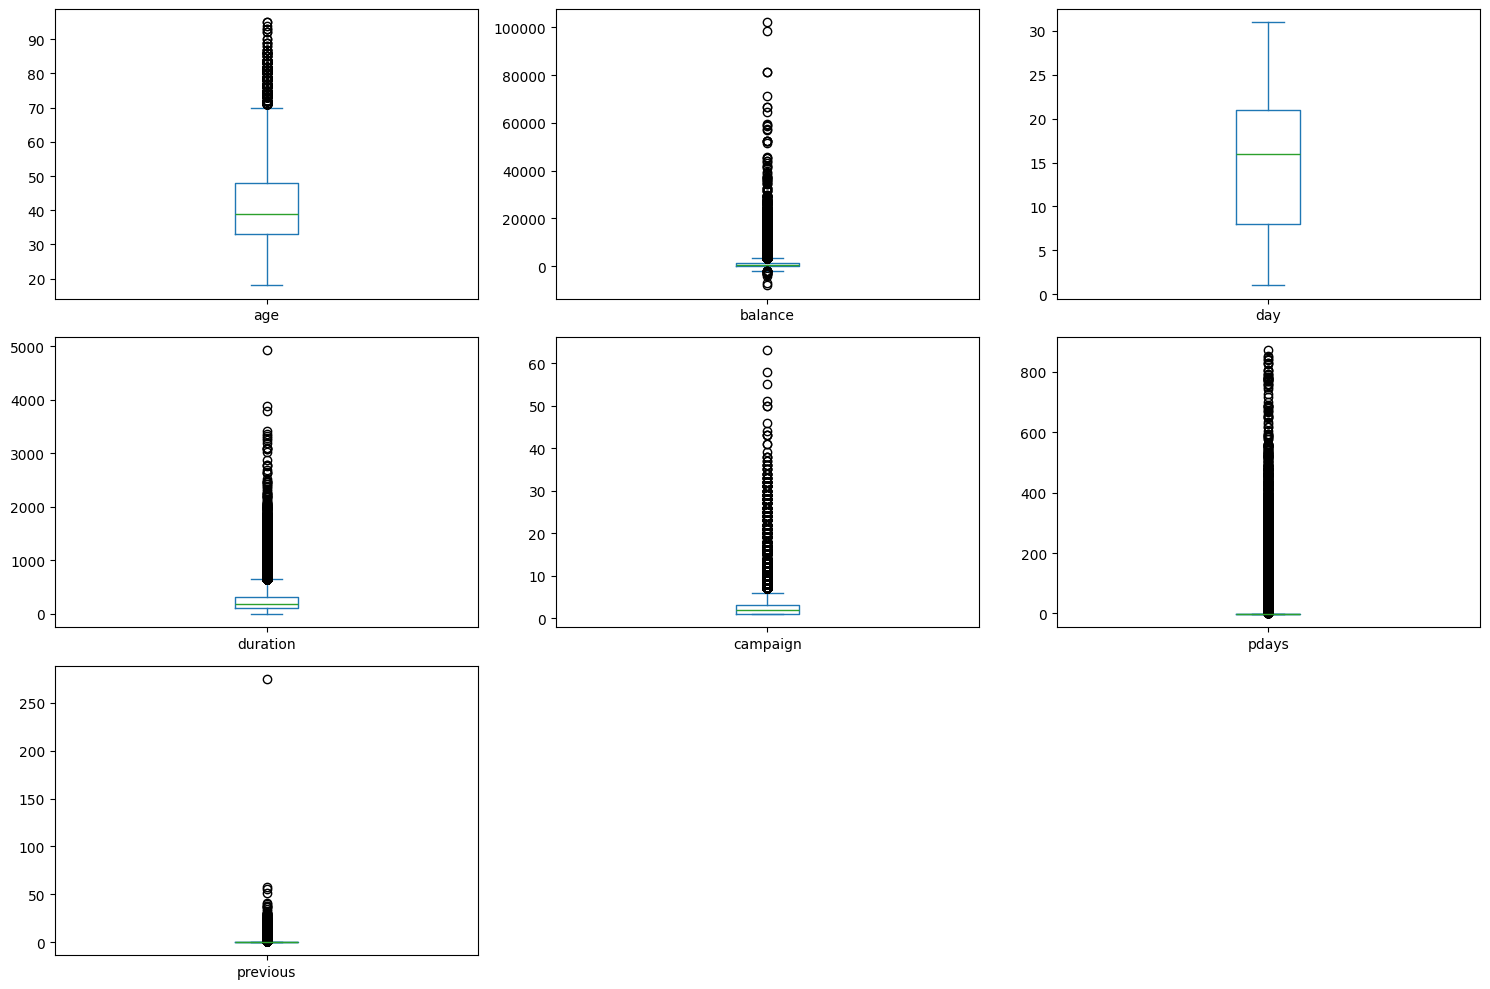

In [15]:
# Checking Outliers in the numerical features using boxplot.
numerical_features = df.select_dtypes(include = [np.number]).columns
df[numerical_features].plot(kind = "box", subplots = True, layout = (3,3), figsize = (15,10))
plt.tight_layout()

In [16]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


```
We will use statistical details of the dataset and will rectify the numerical features.
```

In [17]:
# Checking number of tuple that have values between 30 and 275.
df[(df["previous"] <= 275) & (df["previous"] > 30)].shape[0]

12

```
Only 12 tuples in "previous" which have value between 30 and 275.
```

In [18]:
# Checking number of tuple in "previous" that have value 275.
df[df["previous"]== 275]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
29182,40,management,married,tertiary,no,543,yes,no,cellular,2,feb,349,2,262,275,other,no


```
Only 1 tuple in "previous" having value 275. Thus we can count it as an outlier.
```

In [19]:
# Removing tuple 29182 as it is an outlier.
df.drop(29182, inplace = True)

```
Tuple 29182 removed.
```

In [20]:
# Checking number of tuples between different ranges of values of column "pdays"
for i in range(1,871, 100):
    A = df[(df["pdays"] <= 871) & (df["pdays"] > i)].shape[0]
    print(f"Between {i:3} and 871: {A:4} tuples")
    

Between   1 and 871: 8241 tuples
Between 101 and 871: 6789 tuples
Between 201 and 871: 3941 tuples
Between 301 and 871: 2439 tuples
Between 401 and 871:  233 tuples
Between 501 and 871:  106 tuples
Between 601 and 871:   52 tuples
Between 701 and 871:   32 tuples
Between 801 and 871:   11 tuples


In [21]:
df["pdays"].skew()

np.float64(2.6160189935112586)

<Axes: ylabel='Frequency'>

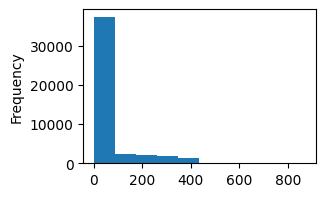

In [22]:
# understanding spread (skewness) of "pdays"
df["pdays"].plot(kind= "hist", figsize = (3,2))

```
All the datapoints seems genuin and can not be considered outliers. But plot is highly skewed which may create concern in ANN model building. Thus we will reduce the skewness using Log transformation method.
```

In [23]:
# Reducing skewness using shift + log transfromation method.
df["pdays"] = np.log1p(df["pdays"] - df["pdays"].min())

<Axes: ylabel='Frequency'>

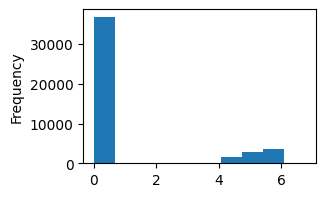

In [24]:
df["pdays"].plot(kind = "hist", figsize = (3,2))

```
Now we can see skewness has reduced significantly. However, there is a gap in the graph but it is fine and good not a problametic for ANN model.
```

In [25]:
# Understanding the scope of outlier in column "campaign"
for i in range(-1,63, 15):
    A = df[(df["campaign"] <= 63) & (df["campaign"] > i)].shape[0]
    print(f"Tuples in column 'campaign' with value between {i:3} and 63 are: {A:5} ")

Tuples in column 'campaign' with value between  -1 and 63 are: 45210 
Tuples in column 'campaign' with value between  14 and 63 are:   614 
Tuples in column 'campaign' with value between  29 and 63 are:    67 
Tuples in column 'campaign' with value between  44 and 63 are:     7 
Tuples in column 'campaign' with value between  59 and 63 are:     1 


In [26]:
# Checking skewness 
df["campaign"].skew()

np.float64(4.898589844637244)

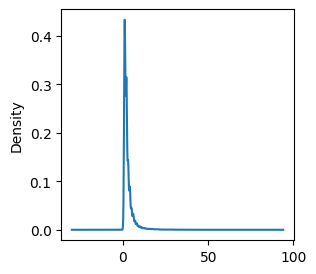

In [27]:
# Ploting "campaign"
df["campaign"].plot(kind = "kde", figsize = (3,3))
plt.show()

In [28]:
# Applying log transformation to reduce skewness 
df["campaign"] = np.log1p(df['campaign'])

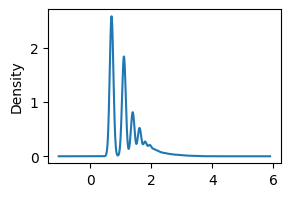

In [29]:
# To check post transformation skewness.
df["campaign"].plot(kind = "kde", figsize = (3,2))
plt.show()

In [30]:
# checking skewness after applying log transformation
df["campaign"].skew()

np.float32(1.3262)

```
There are many genuin points which seems outliers and increase the skewness of the complete feature. We have apply log transformation here also to reduce the right skewness.
```

In [31]:
# Checking outliers in column "duration"
old = 0
for i in range(2400, 4918, 400):
    A = df[(df["duration"] <= i ) & (df["duration"] > 2000 )]["duration"].shape[0]
    print(f"Between {i-400:3} and {i:3} number of tuples are: {A - old}")
    old = A

Between 2000 and 2400 number of tuples are: 30
Between 2400 and 2800 number of tuples are: 14
Between 2800 and 3200 number of tuples are: 7
Between 3200 and 3600 number of tuples are: 5
Between 3600 and 4000 number of tuples are: 2
Between 4000 and 4400 number of tuples are: 0
Between 4400 and 4800 number of tuples are: 0


<Axes: ylabel='Frequency'>

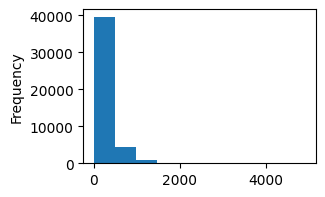

In [32]:
df["duration"].plot(kind = "hist", figsize = (3,2))

```
There are only a few tuples with high values, and we can not say them outleirs. 
```

In [33]:
# Reducing skewness using log transformation.
df["duration"] = np.log1p(df["duration"])

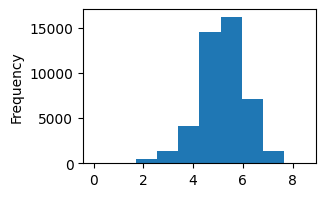

In [34]:
# plot after log transformation.
df["duration"].plot(kind = "hist", figsize = (3,2))
plt.show()

In [35]:
df["duration"].describe()

count    45210.000000
mean         5.171797
std          0.921826
min          0.000000
25%          4.644391
50%          5.198497
75%          5.768321
max          8.500861
Name: duration, dtype: float64

```
Skewness of column 'duration' has been reduced. 
```

In [36]:
# Checking whether customer with high balance subscribed or not.
df[(df["balance"] <= 102127) & (df["balance"] >50000)][["balance", "subscribed"]]

,balance,subscribed
920,58544,no
3197,56831,no
9536,52499,no
12926,58932,no
13154,51439,no
19420,64343,no
19785,66721,no
21192,66653,no
22091,52527,no
26227,98417,no


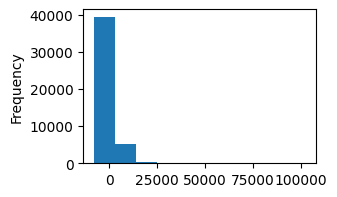

In [37]:
# Ploting 'balance'
df["balance"].plot(kind = 'hist', figsize = (3,2))
plt.show()

In [38]:
# Checking skewness
df['balance'].skew()

np.float64(8.360218531492023)

```
Skewness is very high which may cause issue in ANN model training. Thus there is a need of skewness reduction. 
```

In [39]:
# Applying Shift + log transformation to reduce skewness.
df['balance'] = np.log1p(df['balance'] - df['balance'].min())

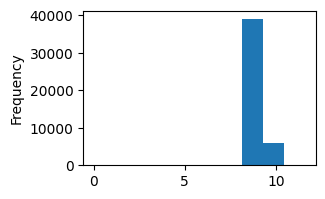

In [40]:
# Post transformation plot
df['balance'].plot(kind = "hist", figsize = (3,2))
plt.show()

In [41]:
# Post transformation skewness
df['balance'].skew()

np.float64(1.0877532629442532)

```
Skewness has reduced after transformation. 
````

### `Exploratory Data Analysis`

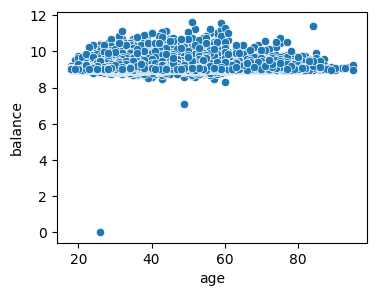

In [42]:
# Understanding the relation between age and balance.
plt.figure(figsize = (4, 3))
sns.scatterplot(x = df["age"], y = df['balance'])
plt.show()

```
Here, we can see the outliers which can cause issue in model building. Thus we will drop these outliers from the dataset.
```

In [43]:
# Finding index number of outliers.
df[(df['age'] <60) & (df["balance"] <8)]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
12909,26,blue-collar,single,secondary,yes,0.00000,no,yes,cellular,7,jul,5.703782,1.386294,0.0,0,unknown,no
15682,49,management,married,tertiary,yes,7.06732,no,yes,cellular,21,jul,5.332719,0.693147,0.0,0,unknown,no


In [44]:
# Droping the outliers.
df.drop([12909, 15682], inplace = True)

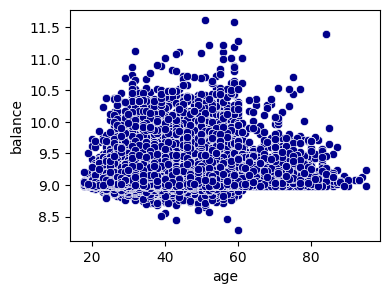

In [112]:
# Post outlier removal plot.
plt.figure(figsize = (4, 3))
sns.scatterplot(x = df["age"], y = df['balance'], color = 'darkblue')
plt.show()

```
Younger customers have high balance with comparision of the older customers.
```

In [46]:
# Finding relation between customer's job and balance of subscribers and not subscribers.
df.groupby(["job", "subscribed"])["balance"].mean().sort_values(ascending = False)

job            subscribed
retired        yes           9.222512
management     yes           9.189904
unknown        yes           9.184631
self-employed  yes           9.183915
technician     yes           9.163144
housemaid      yes           9.161459
unknown        no            9.155788
entrepreneur   yes           9.154170
retired        no            9.152917
management     no            9.143228
student        yes           9.134874
unemployed     no            9.134015
self-employed  no            9.133451
admin.         yes           9.132680
unemployed     yes           9.128960
student        no            9.124081
entrepreneur   no            9.119296
blue-collar    yes           9.118912
housemaid      no            9.117656
services       yes           9.106588
technician     no            9.104814
admin.         no            9.096257
blue-collar    no            9.095863
services       no            9.087806
Name: balance, dtype: float64

```
Though difference in balance is very small, we find interesting observations. Subscribers who are retired and are in management domain have the highest average balance while non subscribers who are blue-collar worker and are in services have the lowest average balance.
```

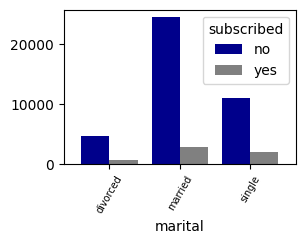

In [76]:
# Checking whether marital status affect the subscription rate or not.
df.groupby('marital')['subscribed'].value_counts().unstack()\
    .plot(kind = 'bar', figsize = (3,2), color = ["darkblue",'gray'], width = 0.8)
plt.xticks(rotation = 60, size = 7)
plt.show()

```
We do not find any substantial relation between marital status and subscription rate.
```

In [48]:
# Understanding whether having a loan affect subscription rate.
df.groupby('loan')['subscribed'].value_counts(normalize= True)*100

loan  subscribed
no    no            87.343939
      yes           12.656061
yes   no            93.316763
      yes            6.683237
Name: proportion, dtype: float64

```
We can clearly see that the customers who do not have loan have high chances to subscribe the term deposit.
```

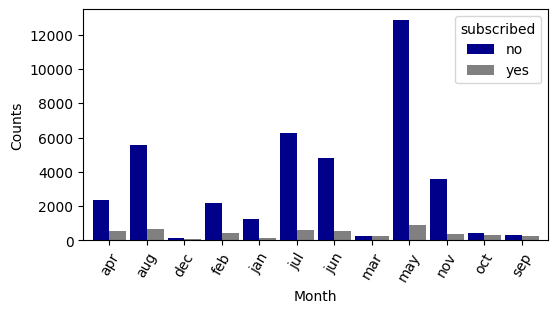

In [49]:
# Finding relation between month and subscription.
df.groupby("month")["subscribed"].value_counts()\
    .unstack().plot(kind = "bar", color =['darkblue', 'gray'], figsize = (6,3), width = .9)
plt.xticks(rotation = 60)
plt.ylabel("Counts")
plt.xlabel("Month")
plt.show()

```
Majority of the campaign drives run in the months of may, jul, august, jun and november. December, October, march, and September are the months in which campaign was run very less. 
``` 

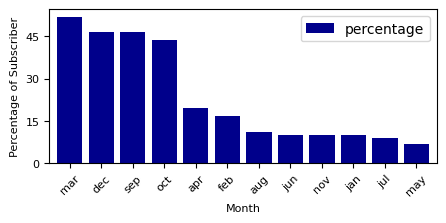

In [50]:
# 
X = df.groupby('month')['subscribed'].value_counts(normalize = True).mul(100).round(2)\
    .reset_index(name = "percentage").sort_values(by = "percentage", ascending = False)
X[X['subscribed'] == 'yes'][['month', 'percentage']].set_index('month')\
    .plot(kind = 'bar', figsize = (5,2), width = 0.8, color = ["darkblue"])
plt.ylabel("Percentage of Subscriber", size = 8)
plt.yticks(np.arange(0, 60, 15), size = 8)
plt.xticks(rotation = 45, size = 8)
plt.xlabel('Month', size = 8)
plt.show()
  

```
But here, We can see that percentage of subscribers is high in the months of march, december, september, and october while it reduces in the month of april, august and january etc.
```

In [51]:
# Does the customer subscribe term deposit if they have housing loan and default credit.
df[(df['default'] == 'yes') & (df['housing'] == 'yes') & (df['subscribed'] == 'yes')].shape[0]

29

```
Only 29 subscribers who also have housing loan and default credit. This small number clearly show that customers are less likely to subscribe if they already in debt of loans or credits.
```

In [59]:
# Counting number of success in previous campaign
M = df[df['poutcome'] == "success"].shape[0]
M

1511

In [62]:
# Number of subscriber with whom previous campaign was successful.
N = df[(df['poutcome'] == "success") & (df["subscribed"] == 'yes')].shape[0]
print("No of success in previous campaign:",N)
print('Those with whom previous campaing status was successful but not subscribed:',M-N)

No of success in previous campaign: 978
Those with whom previous campaing status was successful but not subscribed: 533


```
We can see that there are 533 customers with whom previous outcome was successful but did not subscribe the term deposit.
```

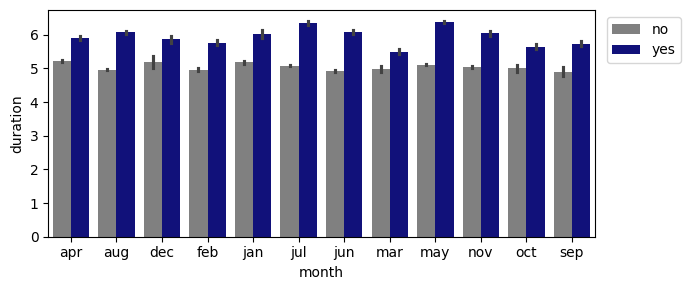

In [92]:
# Analysing impact of duration on subscription
plt.figure(figsize = (7,3))
sns.barplot(x = 'month', y = 'duration', data = df, hue = 'subscribed', 
            palette = {'yes': 'darkblue', 'no':'gray'})
plt.legend(bbox_to_anchor = (1.17, 1))
plt.tight_layout()
plt.show()

```
It is evident that if the customers are given good enough time to consult there are high chances of their conversion.
```

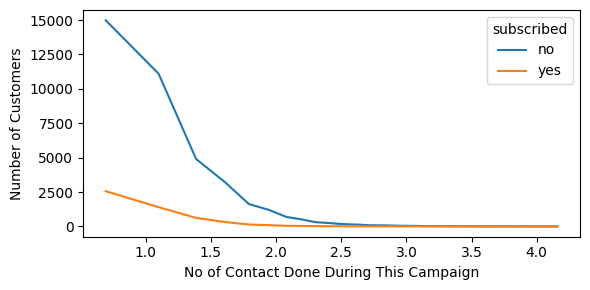

In [110]:
# Understanding the impact of current campaign on subscription
B = df.groupby('campaign')['subscribed'].value_counts().reset_index()
plt.figure(figsize = (6,3))
sns.lineplot(B, x = "campaign", y = "count", hue = 'subscribed')
plt.xlabel("No of Contact Done During This Campaign")
plt.ylabel("Number of Customers")
plt.tight_layout()

```
Majority of the subscribers were contacted fewer time which means those who want to join term deposit join it in a very few contacts and those who do not wish to join are not converted even if contacted multiple times.
``` 

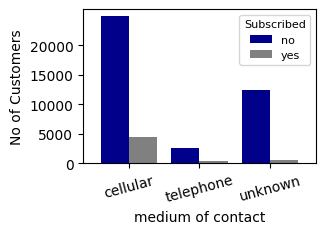

In [129]:
df.groupby('contact')['subscribed'].value_counts()\
    .unstack().plot(kind = 'bar', figsize = (3, 2), color = ['darkblue', 'gray'], width = 0.8)
plt.xticks(rotation = 15)
plt.legend(title = "Subscribed", fontsize = 8, title_fontsize = 8)
plt.xlabel("medium of contact")
plt.ylabel("No of Customers")
plt.yticks(np.arange(0,25000, 5000))
plt.tight_layout
plt.show()

```
Most contacts were established via cellular phones. Customers were also contacted with unknown mediums but very few subscribed the term deposit. Maximum conversions took place when customer contacted via cellular phone. 
```

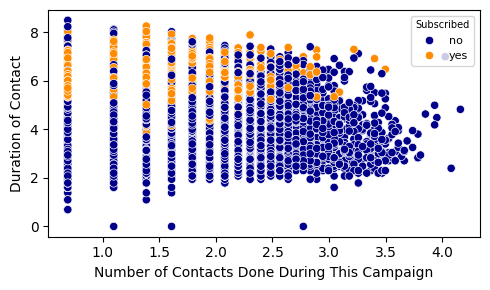

In [152]:
# Scatter plot between campaign and duration with subscribed as hue.
plt.figure(figsize = (5,3))
sns.scatterplot(df, x = "campaign", y = "duration", hue = 'subscribed',\
    palette = {"no":"darkblue", "yes":"darkorange"} )
plt.legend(title = "Subscribed",title_fontsize = 7, fontsize = 8,
           loc = "upper right")
plt.xlabel("Number of Contacts Done During This Campaign")
plt.ylabel("Duration of Contact")
plt.tight_layout()
plt.show()

```
It is clearly visible that majoriy of the customers subscribed to the term deposit policy within a few contacts, but communication with them held for a longer period. Perhaps more time was taken by the customers to know the details of the policy, and they subscribed it only after they got satisfy with it.
```


In [153]:
df.sample(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
23586,44,management,married,tertiary,no,9.016391,yes,no,cellular,28,aug,5.318120,1.609438,0.0,0,unknown,no
8928,36,management,married,tertiary,no,9.108751,yes,no,unknown,4,jun,3.555348,1.098612,0.0,0,unknown,no
42302,22,student,single,unknown,no,9.039552,no,no,cellular,16,nov,5.902633,0.693147,0.0,0,unknown,no
42676,32,admin.,married,secondary,no,9.034319,no,no,cellular,14,jan,5.905362,1.098612,0.0,0,unknown,yes
15814,42,technician,married,secondary,yes,8.996528,yes,no,cellular,21,jul,5.676754,0.693147,0.0,0,unknown,no


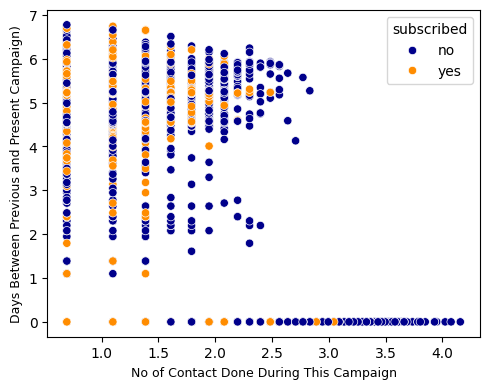

In [168]:
# Scatterplot between pdays and campaign with subscribed as hue.
plt.figure(figsize = (5,4))
sns.scatterplot(df, y = "pdays", x = "campaign", hue = "subscribed",\
        palette = {"yes": "darkorange", "no": "darkblue"})
plt.ylabel("Days Between Previous and Present Campaign)", size = 9)
plt.xlabel("No of Contact Done During This Campaign", size = 9)
plt.tight_layout()
plt.show()

```
Customers majorly subscribe the policy in initial contacts while gap days between previous and present campaign does not affect the subscription rate.
```